# Loan Payback Prediction Project

**Goal**: Predict the probability that a borrower will pay back their loan.

**Data Source**: Kaggle - Playground Series - Season 5, Episode 11: Loan Default Prediction ([Competition Link](https://www.kaggle.com/competitions/playground-series-s5e11/overview))

In [ ]:
#importing libraries
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier # Decision Tree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer

### Reading in the dataset

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/loan_dataset_20000.csv")

Mounted at /content/drive


## EDA

In [ ]:
df.head(10)

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1
5,28,Male,Single,High School,55559.80,4629.98,Employed,0.081,774,12724.02,...,60,287.75,B1,3,76147.61,14885.25,0,0,1,1
6,41,Male,Single,Bachelor's,24642.88,2053.57,Unemployed,0.165,742,5905.27,...,36,197.50,B3,6,18380.15,12683.33,3,0,3,0
7,59,Female,Single,Bachelor's,52610.69,4384.22,Employed,0.135,810,15136.35,...,36,477.47,A3,4,75260.33,13768.13,0,0,0,1
8,39,Other,Single,High School,62922.05,5243.50,Employed,0.074,724,500.00,...,36,16.12,C4,6,42759.40,15596.93,3,0,4,1
9,43,Female,Single,High School,53439.89,4453.32,Employed,0.375,796,14712.38,...,36,487.33,B1,4,40629.06,15965.92,2,0,2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_open_account

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
display(df.describe(include='all'))

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.000000,20000,20000,20000,20000.000000,20000.000000,20000,20000.000000,20000.00000,20000.000000,...,20000.00000,20000.000000,20000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
unique,NaN,3,4,5,NaN,NaN,5,NaN,NaN,NaN,...,NaN,NaN,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Female,Single,Bachelor's,NaN,NaN,Employed,NaN,NaN,NaN,...,NaN,NaN,C3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,10034,9031,8045,NaN,NaN,13007,NaN,NaN,NaN,...,NaN,NaN,1514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,48.027000,NaN,NaN,NaN,43549.637765,3629.136466,NaN,0.177019,679.25695,15129.300909,...,43.22280,455.625794,NaN,5.011800,48649.824769,24333.394631,1.990150,0.061800,2.489150,0.799900
std,15.829352,NaN,NaN,NaN,28668.579671,2389.048326,NaN,0.105059,69.63858,8605.405513,...,11.00838,274.622125,NaN,2.244529,32423.378128,22313.845395,1.474945,0.285105,1.631384,0.400085
min,21.000000,NaN,NaN,NaN,6000.000000,500.000000,NaN,0.010000,373.00000,500.000000,...,36.00000,9.430000,NaN,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,NaN,NaN,NaN,24260.752500,2021.730000,NaN,0.096000,632.00000,8852.695000,...,36.00000,253.910000,NaN,3.000000,27180.492500,9592.572500,1.000000,0.000000,1.000000,1.000000
50%,48.000000,NaN,NaN,NaN,36585.260000,3048.770000,NaN,0.160000,680.00000,14946.170000,...,36.00000,435.595000,NaN,5.000000,40241.615000,18334.555000,2.000000,0.000000,2.000000,1.000000
75%,62.000000,NaN,NaN,NaN,54677.917500,4556.495000,NaN,0.241000,727.00000,20998.867500,...,60.00000,633.595000,NaN,6.000000,60361.257500,31743.327500,3.000000,0.000000,3.000000,1.000000


In [ ]:
df.columns

Index(['age', 'gender', 'marital_status', 'education_level', 'annual_income',
       'monthly_income', 'employment_status', 'debt_to_income_ratio',
       'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate',
       'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts',
       'total_credit_limit', 'current_balance', 'delinquency_history',
       'public_records', 'num_of_delinquencies', 'loan_paid_back'],
      dtype='object')

### Visualisations

#### Examining the distributions and correlations of numerical features

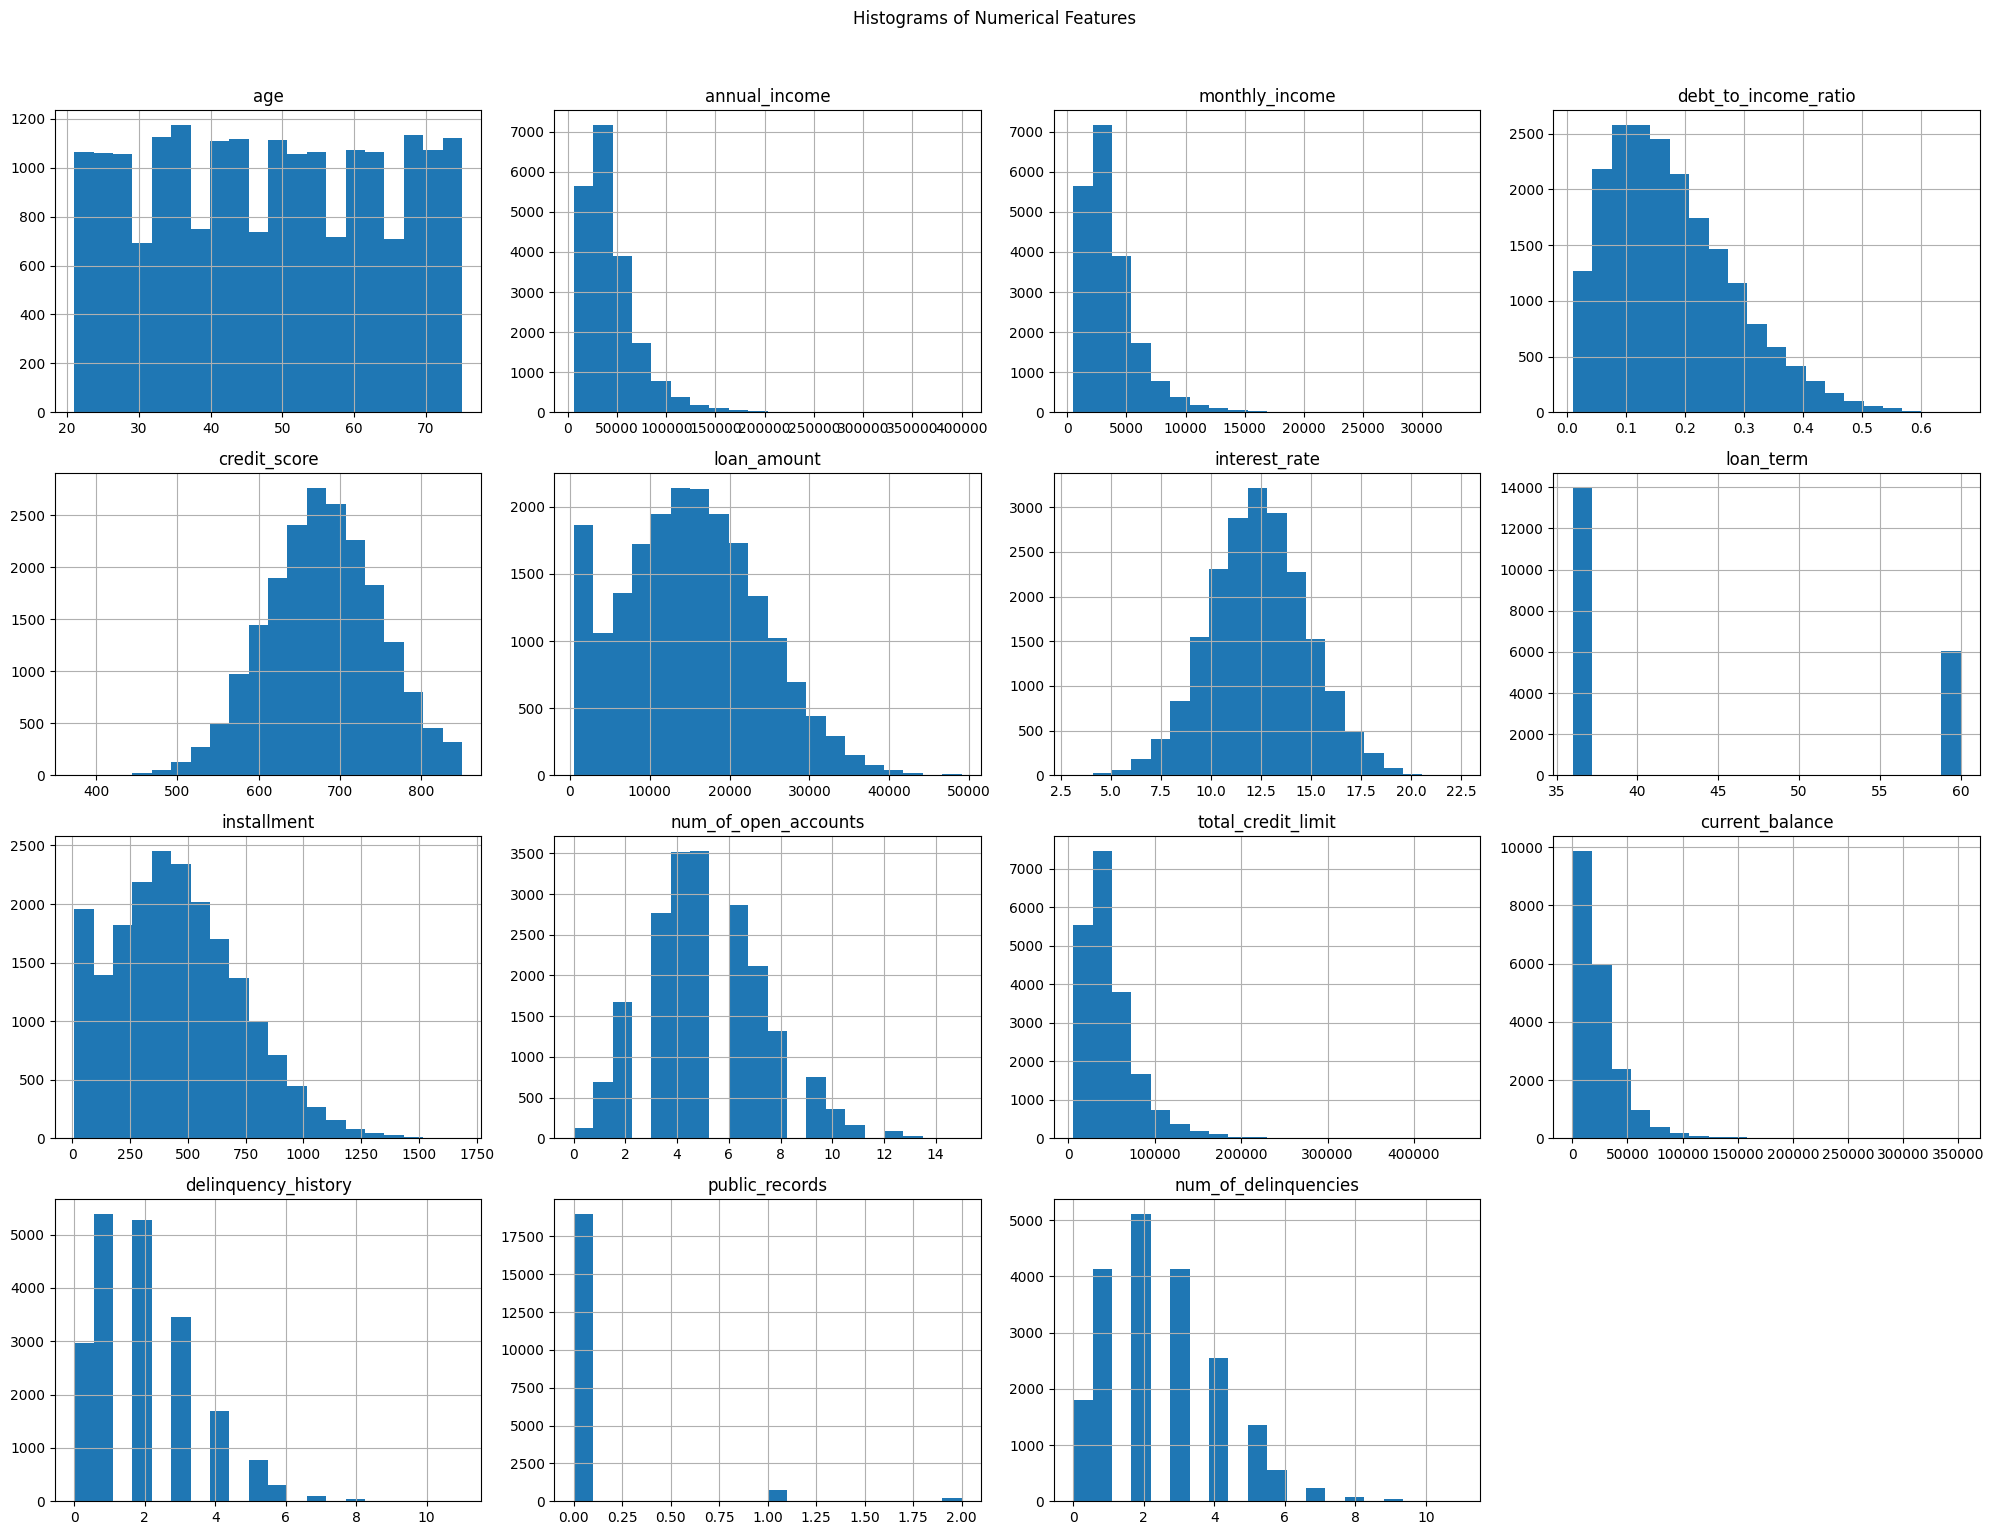

In [ ]:
# isolating columns with numerical data
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Removing the target variable from the list for plotting distributions
numerical_features = [col for col in numerical_cols if col != 'loan_paid_back']

# Plot histograms for numerical features
df[numerical_features].hist(figsize=(20, 15), bins=20)
plt.suptitle('Histograms of Numerical Features', y=1.02)
plt.tight_layout()
plt.show()


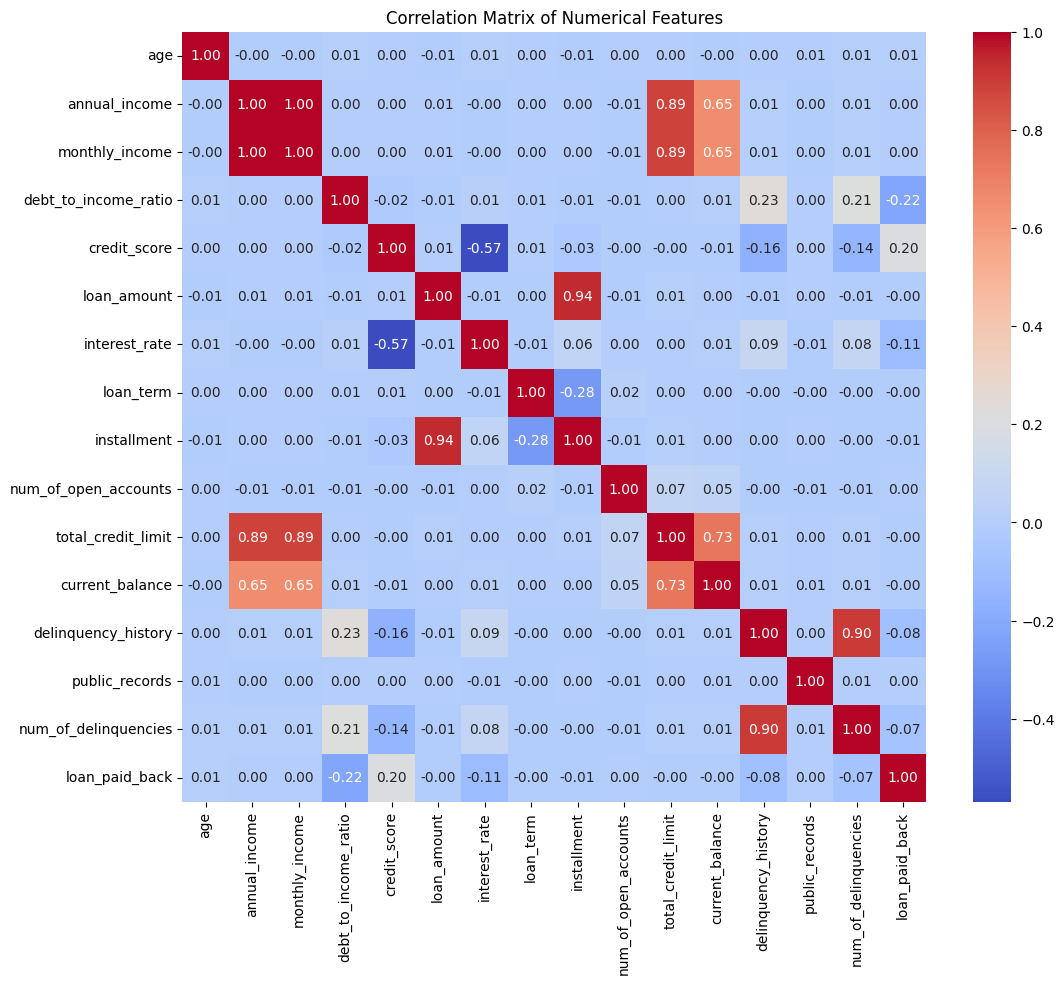

In [ ]:
# Calculate and display the correlation matrix
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

#### Correlation Analysis:
- Debt-to-income ratio and credit-score appear to have the greatest influence on whether the loan will be paid back
- The higher the debt to income ration the higher the risk of default on loan (negative correlation), and the higher the credit score the less the risk (positive correlation)
- delinquency features also seem to have negative correlation with loan pay-back (if one has defaulted on a loan before then risk for defaulting is higher)

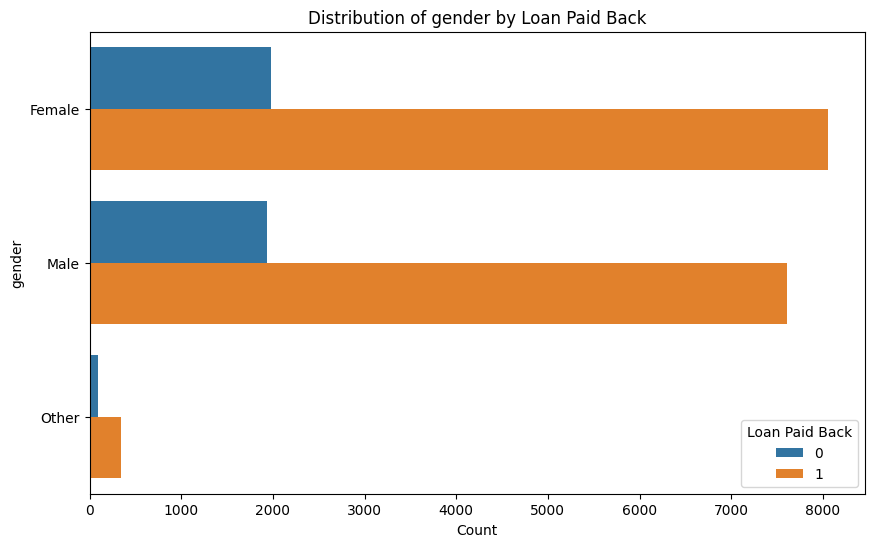

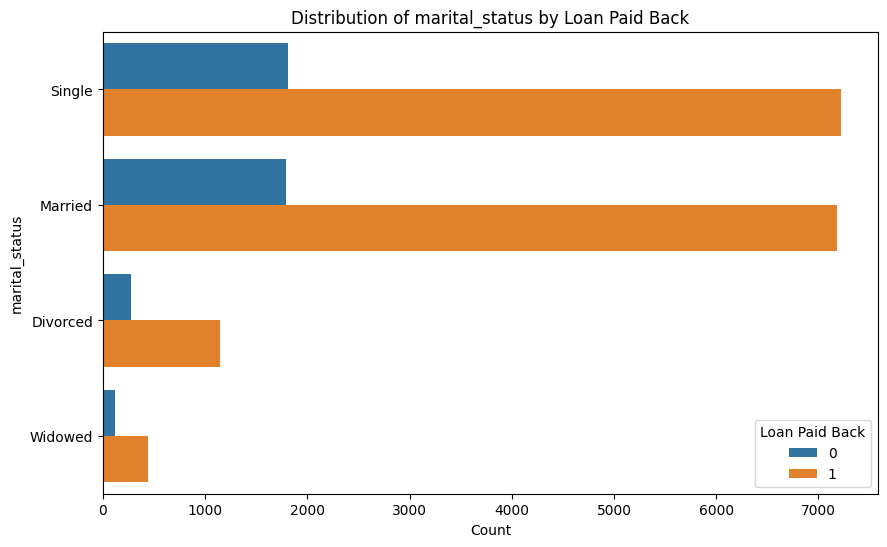

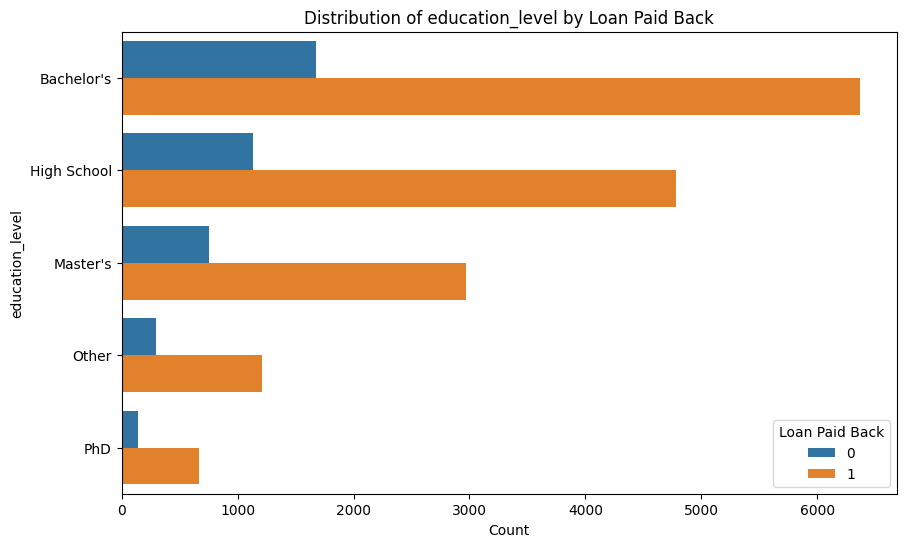

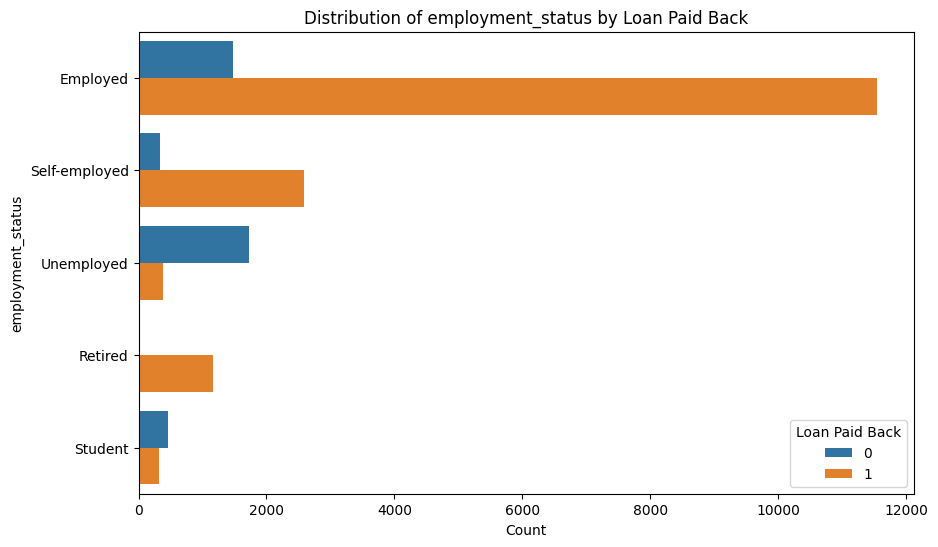

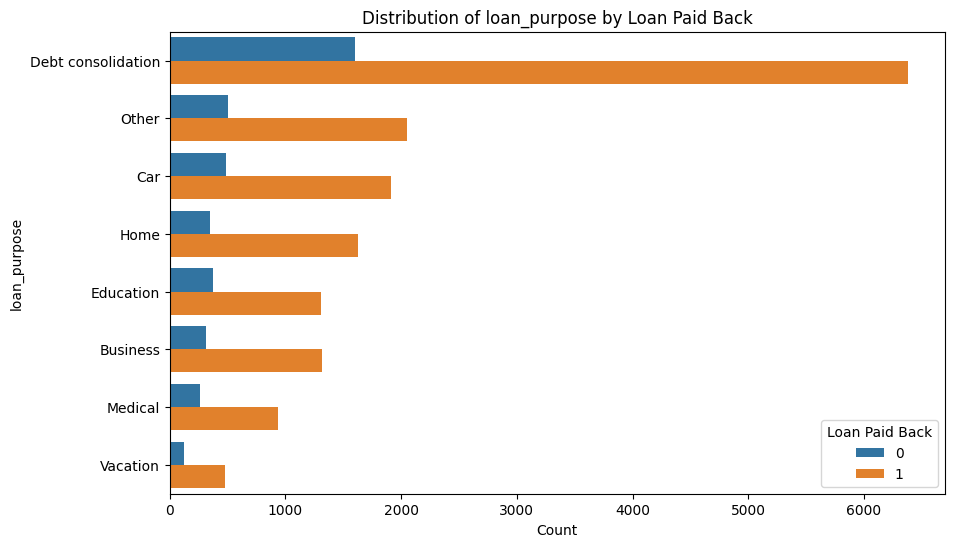

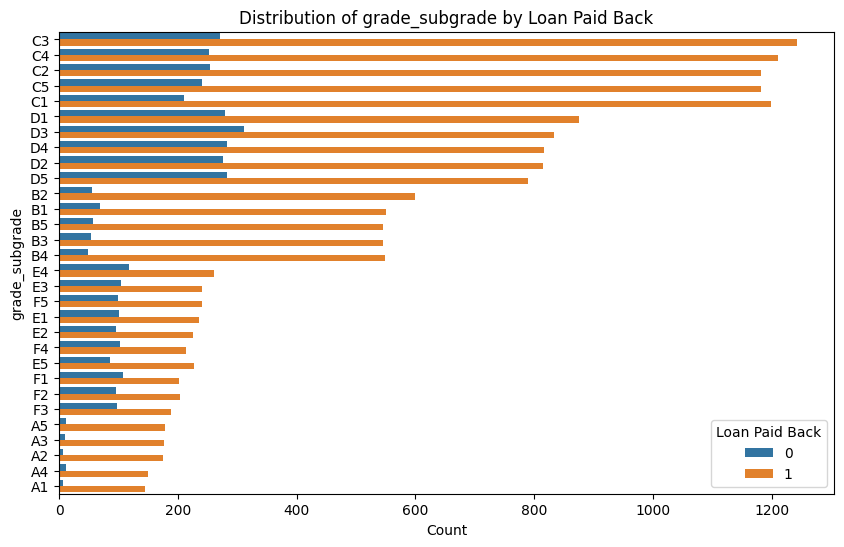

In [ ]:
# isolate categorical feature columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
       # Bar plot for relationship with target variable
    plt.figure(figsize=(10, 6))
    sns.countplot(y=col, hue='loan_paid_back', data=df, order = df[col].value_counts().index)
    plt.title(f'Distribution of {col} by Loan Paid Back')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.legend(title='Loan Paid Back', loc='lower right')
    plt.show()

#### Feature Selection

*Features identified as potentially necessary for the classification model:*
Numerical features with relationship observed in box plots and/or correlation matrix.
- debt_to_income_ratio
- credit_score
- interest_rate
- installment
- annual_income
- monthly_income
- total_credit_limit
- current_balance
- delinquency_history
- num_of_delinquencies
- num_of_open_accounts


Categorical features where different proportions of loan paid back observed in bar plots across the two target categories.
- gender
- marital_status
- education_level
- employment_status
- loan_purpose
- grade_subgrade

#### Feature Engineering

*Idea 1: Income to Loan Amount Ratio*
This ratio could indicate the borrower's capacity to repay the loan relative to their income. A higher ratio might suggest a higher risk of default.
It could help the model capture cases where a high income is offset by a very large loan, or vice versa, potentially improving predictive power for loan repayment.

*Idea 2: Credit Score and Debt-to-Income Ratio Interaction*
A high debt-to-income ratio combined with a low credit score is likely a strong indicator of higher default risk.
This feature could allow the model to better differentiate between high and low-risk borrowers by considering the combined impact of creditworthiness and existing debt burden.


In [ ]:
# 1: Income to Loan Amount Ratio
df['income_to_loan_ratio'] = df['annual_income'] / df['loan_amount']

# 2: Credit Score and Debt-to-Income Ratio Interaction
df['credit_score_dti_interaction'] = df['credit_score'] * df['debt_to_income_ratio']


*Consolidated List of Potentially Useful Features:*
   Based on the analysis of both original and engineered features, the following features are likely to be most useful for predicting `loan_paid_back`:
   - `credit_score`
   - `interest_rate`
   - `debt_to_income_ratio`
   - `installment`
   - `annual_income`
   - `monthly_income`
   - `total_credit_limit`
   - `current_balance`
   - `delinquency_history`
   - `num_of_delinquencies`
   - `num_of_open_accounts`
   - `gender`
   - `marital_status`
   - `education_level`
   - `employment_status`
   - `loan_purpose`
   - `grade_subgrade`
   - `income_to_loan_ratio`
   - `credit_score_dti_interaction`

## Preprocessing Pipeline

In [ ]:
df.columns

Index(['age', 'gender', 'marital_status', 'education_level', 'annual_income',
       'monthly_income', 'employment_status', 'debt_to_income_ratio',
       'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate',
       'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts',
       'total_credit_limit', 'current_balance', 'delinquency_history',
       'public_records', 'num_of_delinquencies', 'loan_paid_back',
       'income_to_loan_ratio', 'credit_score_dti_interaction'],
      dtype='object')

In [ ]:
# separating target from features
X = df.drop(columns=['loan_paid_back'])
y = df['loan_paid_back']

In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print ("numerical: ",numerical_features)

print ("\ncategorical: ", categorical_cols)

numerical:  ['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'public_records', 'num_of_delinquencies']

categorical:  ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']


In [ ]:
# Setting up preprocessing pipelines

# StandardScalar for numerical data
numeric_pipe = Pipeline([
    ('scaler', StandardScaler())
])

# One hot encoder for categorical data
categorical_pipe = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])


preprocess = ColumnTransformer([
    ('num', numeric_pipe, numerical_features),
    ('cat', categorical_pipe, categorical_cols)
])

In [ ]:

# Defining the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Creating a pipeline for each model that includes preprocessing and the model
pipelines = {name: Pipeline([('preprocessor', preprocess), ('classifier', model)])
             for name, model in models.items()}

# Training and evaluating each model
results = {}
for name, pipeline in pipelines.items():
    print(f"Training {name}...")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1] # Probability of the positive class

    # Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }
    print(f"{name} Evaluation:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  ROC AUC: {roc_auc:.4f}")
    print("-" * 30)

# Displaying results in a DataFrame for easy comparison
results_df = pd.DataFrame(results).T
display(results_df)

Training Logistic Regression...
Logistic Regression Evaluation:
  Accuracy: 0.8810
  Precision: 0.8956
  Recall: 0.9626
  F1 Score: 0.9279
  ROC AUC: 0.8822
------------------------------
Training Random Forest...
Random Forest Evaluation:
  Accuracy: 0.8942
  Precision: 0.8902
  Recall: 0.9890
  F1 Score: 0.9370
  ROC AUC: 0.8802
------------------------------
Training Gradient Boosting...
Gradient Boosting Evaluation:
  Accuracy: 0.9000
  Precision: 0.8916
  Recall: 0.9953
  F1 Score: 0.9406
  ROC AUC: 0.8961
------------------------------
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:49:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Evaluation:
  Accuracy: 0.8918
  Precision: 0.8940
  Recall: 0.9802
  F1 Score: 0.9351
  ROC AUC: 0.8768
------------------------------


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.88100,0.895614,0.962602,0.927901,0.882193
Random Forest,0.89425,0.890240,0.989001,0.937025,0.880173
Gradient Boosting,0.90000,0.891610,0.995286,0.940600,0.896084
XGBoost,0.89175,0.893952,0.980201,0.935092,0.876777


#### Results:

- Gradient Boosting performed best with a slightly better ROC AUC (0.8961) and higher values across all metrics

## Optimizing with Optuna

In [ ]:
#installing optuna package
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 23.0 MB/s eta 0:00:00


In [ ]:
# importing optuna
import optuna

#### Optimizing the Best Performing Model (Gradient Boosting) with Optuna

In [ ]:
# Re-defining the preprocessing pipeline globally for use in the objective function
preprocess_for_optuna = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), numerical_features),
    ('cat', Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
])

def objective_gb(trial):
    # Hyperparameters to tune for GradientBoostingClassifier
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    max_depth = trial.suggest_int('max_depth', 3, 15)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)

    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        random_state=42
    )

    pipeline = Pipeline([
        ('preprocessor', preprocess_for_optuna),
        ('classifier', model)
    ])

    # Train and evaluate the model using cross-validation
    score = cross_val_score(pipeline, X_train, y_train, n_jobs=-1, cv=3, scoring='roc_auc')
    return score.mean()

# Create an Optuna study and optimize the objective function for Gradient Boosting
study_gb = optuna.create_study(direction='maximize', study_name='GradientBoosting_Optimization')
study_gb.optimize(objective_gb, n_trials=50) # Run 50 trials

print("Number of finished trials: ", len(study_gb.trials))
print("Best trial:")
trial_gb = study_gb.best_trial

print("  Value: ", trial_gb.value)
print("  Params: ")
for key, value in trial_gb.params.items():
    print("    {}: {}".format(key, value))


[I 2025-11-19 09:05:47,987] A new study created in memory with name: GradientBoosting_Optimization
[I 2025-11-19 09:09:12,483] Trial 0 finished with value: 0.8752862757665406 and parameters: {'n_estimators': 336, 'learning_rate': 0.20364071650501442, 'max_depth': 15, 'subsample': 0.9153922443050792}. Best is trial 0 with value: 0.8752862757665406.
[I 2025-11-19 09:09:57,741] Trial 1 finished with value: 0.8834988835861274 and parameters: {'n_estimators': 248, 'learning_rate': 0.2305931732762425, 'max_depth': 3, 'subsample': 0.9277827410530347}. Best is trial 1 with value: 0.8834988835861274.
[I 2025-11-19 09:12:53,118] Trial 2 finished with value: 0.8746214093698995 and parameters: {'n_estimators': 462, 'learning_rate': 0.09863092320576007, 'max_depth': 9, 'subsample': 0.668790430937218}. Best is trial 1 with value: 0.8834988835861274.
[I 2025-11-19 09:13:32,851] Trial 3 finished with value: 0.8874758576062348 and parameters: {'n_estimators': 103, 'learning_rate': 0.010204923882260443,

Number of finished trials:  50
Best trial:
  Value:  0.8940524231257304
  Params: 
    n_estimators: 360
    learning_rate: 0.016530362583391394
    max_depth: 5
    subsample: 0.6912412594681973


#### Retraining Gradient Boosting with Optuna's Best Hyperparameters

In [ ]:
# Get the best hyperparameters from the Optuna study for Gradient Boosting
best_params_gb = study_gb.best_trial.params

# Create the optimized GradientBoostingClassifier model with the best parameters
optimized_gb_model = GradientBoostingClassifier(
    n_estimators=best_params_gb['n_estimators'],
    learning_rate=best_params_gb['learning_rate'],
    max_depth=best_params_gb['max_depth'],
    subsample=best_params_gb['subsample'],
    random_state=42 # Ensure reproducibility
)

# Create the final pipeline with the preprocessor and the optimized GB model
final_gb_pipeline = Pipeline([
    ('preprocessor', preprocess_for_optuna), # Use the same preprocessor as in Optuna
    ('classifier', optimized_gb_model)
])

# Train the final pipeline on the entire training set (X_train, y_train)
print("Training the final Optimized Gradient Boosting Model...")
final_gb_pipeline.fit(X_train, y_train)
print("Training complete.")

# Evaluate the fully optimized model on the held-out test set (X_test, y_test)
y_pred_final_gb = final_gb_pipeline.predict(X_test)
y_proba_final_gb = final_gb_pipeline.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_final_gb = accuracy_score(y_test, y_pred_final_gb)
precision_final_gb = precision_score(y_test, y_pred_final_gb)
recall_final_gb = recall_score(y_test, y_pred_final_gb)
f1_final_gb = f1_score(y_test, y_pred_final_gb)
roc_auc_final_gb = roc_auc_score(y_test, y_proba_final_gb)

print("\nOptimized Gradient Boosting Model Final Evaluation on Test Set:")
print(f"  Accuracy: {accuracy_final_gb:.4f}")
print(f"  Precision: {precision_final_gb:.4f}")
print(f"  Recall: {recall_final_gb:.4f}")
print(f"  F1 Score: {f1_final_gb:.4f}")
print(f"  ROC AUC: {roc_auc_final_gb:.4f}")

# Displaying results in a DataFrame for easy comparison
final_results = {
    "Optimized Gradient Boosting": {
        "Accuracy": accuracy_final_gb,
        "Precision": precision_final_gb,
        "Recall": recall_final_gb,
        "F1 Score": f1_final_gb,
        "ROC AUC": roc_auc_final_gb
    }
}
final_results_df = pd.DataFrame(final_results).T

display(final_results_df)


Training the final Optimized Gradient Boosting Model...
Training complete.

Optimized Gradient Boosting Model Final Evaluation on Test Set:
  Accuracy: 0.8970
  Precision: 0.8908
  Recall: 0.9921
  F1 Score: 0.9387
  ROC AUC: 0.8989


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Optimized Gradient Boosting,0.897,0.890801,0.992143,0.938745,0.898897






---

#### Demonstrating Optimization of Random Forest Model with Optuna
For demonstration purposes, 5 runs used, however, for a more robust optimization and potentially better model performance, a higher number of trials is generally preferred (eg. 50 or more).

In [ ]:

# Re-defining the preprocessing pipeline globally for use in the objective function
preprocess_for_optuna = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), numerical_features),
    ('cat', Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
])

def objective(trial):
    # Hyperparameters to tune for RandomForestClassifier
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 5, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=42,
        n_jobs=-1 # Use all available cores
    )

    pipeline = Pipeline([
        ('preprocessor', preprocess_for_optuna),
        ('classifier', model)
    ])

    # Train and evaluate the model using cross-validation
    # We'll use ROC AUC as the optimization metric, as it was a key metric in your previous evaluation
    score = cross_val_score(pipeline, X_train, y_train, n_jobs=-1, cv=3, scoring='roc_auc')
    return score.mean()

# Create an Optuna study and optimize the objective function
# We'll maximize the ROC AUC score
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5) # Run 5 trials for demonstration purposes, however, not

print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial

print("  Value: ", trial.value)
print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))


[I 2025-11-19 10:59:13,907] A new study created in memory with name: no-name-dd93c8df-66df-42eb-9447-399cbe5b3c5e
[I 2025-11-19 11:00:05,363] Trial 0 finished with value: 0.8790142512886305 and parameters: {'n_estimators': 482, 'max_depth': 42, 'min_samples_split': 8, 'min_samples_leaf': 3, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8790142512886305.
[I 2025-11-19 11:00:24,425] Trial 1 finished with value: 0.8746192022265363 and parameters: {'n_estimators': 261, 'max_depth': 34, 'min_samples_split': 8, 'min_samples_leaf': 3, 'criterion': 'gini'}. Best is trial 0 with value: 0.8790142512886305.
[I 2025-11-19 11:00:29,450] Trial 2 finished with value: 0.8713431719412381 and parameters: {'n_estimators': 51, 'max_depth': 47, 'min_samples_split': 13, 'min_samples_leaf': 10, 'criterion': 'gini'}. Best is trial 0 with value: 0.8790142512886305.
[I 2025-11-19 11:00:33,566] Trial 3 finished with value: 0.8755102640125768 and parameters: {'n_estimators': 58, 'max_depth': 31, 'min_sam

Number of finished trials:  5
Best trial:
  Value:  0.8790142512886305
  Params: 
    n_estimators: 482
    max_depth: 42
    min_samples_split: 8
    min_samples_leaf: 3
    criterion: entropy


In [ ]:
# Get the best hyperparameters from the Optuna study for Random Forest
best_params_rf = study.best_trial.params

# Create the optimized RandomForestClassifier model with the best parameters
optimized_rf_model = RandomForestClassifier(
    n_estimators=best_params_rf['n_estimators'],
    max_depth=best_params_rf['max_depth'],
    min_samples_split=best_params_rf['min_samples_split'],
    min_samples_leaf=best_params_rf['min_samples_leaf'],
    criterion=best_params_rf['criterion'],
    random_state=42, # Ensure reproducibility
    n_jobs=-1
)

# Create the final pipeline with the preprocessor and the optimized RF model
final_rf_pipeline = Pipeline([
    ('preprocessor', preprocess_for_optuna), # Use the same preprocessor as in Optuna
    ('classifier', optimized_rf_model)
])

# Train the final pipeline on the entire training set (X_train, y_train)
print("Training the final Optimized Random Forest Model...")
final_rf_pipeline.fit(X_train, y_train)
print("Training complete.")

# Evaluate the fully optimized model on the held-out test set (X_test, y_test)
y_pred_final_rf = final_rf_pipeline.predict(X_test)
y_proba_final_rf = final_rf_pipeline.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_final_rf = accuracy_score(y_test, y_pred_final_rf)
precision_final_rf = precision_score(y_test, y_pred_final_rf)
recall_final_rf = recall_score(y_test, y_pred_final_rf)
f1_final_rf = f1_score(y_test, y_pred_final_rf)
roc_auc_final_rf = roc_auc_score(y_test, y_proba_final_rf)

print("\nOptimized Random Forest Model Final Evaluation on Test Set:")
print(f"  Accuracy: {accuracy_final_rf:.4f}")
print(f"  Precision: {precision_final_rf:.4f}")
print(f"  Recall: {recall_final_rf:.4f}")
print(f"  F1 Score: {f1_final_rf:.4f}")
print(f"  ROC AUC: {roc_auc_final_rf:.4f}")

# Create a DataFrame for the optimized Random Forest results
optimized_rf_results_df = pd.DataFrame({
    "Optimized Random Forest": {
        "Accuracy": accuracy_final_rf,
        "Precision": precision_final_rf,
        "Recall": recall_final_rf,
        "F1 Score": f1_final_rf,
        "ROC AUC": roc_auc_final_rf
    }
}).T



Training the final Optimized Random Forest Model...
Training complete.

Optimized Random Forest Model Final Evaluation on Test Set:
  Accuracy: 0.8945
  Precision: 0.8903
  Recall: 0.9893
  F1 Score: 0.9372
  ROC AUC: 0.8843


## Combined Model Performance Comparison

In [ ]:
# Combine all results (initial models, optimized Gradient Boosting, optimized Random Forest)
combined_all_results_df = pd.concat([results_df, final_results_df, optimized_rf_results_df])

display(combined_all_results_df)


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.88100,0.895614,0.962602,0.927901,0.882193
Random Forest,0.89425,0.890240,0.989001,0.937025,0.880173
Gradient Boosting,0.90000,0.891610,0.995286,0.940600,0.896084
XGBoost,0.89175,0.893952,0.980201,0.935092,0.876777
Optimized Gradient Boosting,0.89700,0.890801,0.992143,0.938745,0.898897
Optimized Random Forest,0.89450,0.890271,0.989315,0.937184,0.884281


## Impact of Optuna Hyperparameter Optimization: A Brief Report

*   **Gradient Boosting Enhancement:** Optuna successfully improved the Gradient Boosting model's ROC AUC from **0.8961** to **0.8989**, establishing it as the top-performing model in terms of class separation ability.
*   **Random Forest Improvement:** The Random Forest model also saw a marginal increase in its ROC AUC, moving from **0.8802** to **0.8843** after optimization.
*   **Mixed Metric Results:** While ROC AUC generally improved, other metrics like Accuracy and F1 Score showed mixed changes.
*   **Conclusion:** Optuna effectively fine-tuned the models, particularly enhancing their discriminative power (ROC AUC), although the impact on other performance metrics varied based on the specific model and the targeted optimization goal.

## Generating Submission File

In [ ]:
# Predict probabilities for the positive class (loan_paid_back = 1) on the test set
# Using the optimized Gradient Boosting pipeline, as it had the best ROC AUC
y_pred_proba_submission = final_gb_pipeline.predict_proba(X_test)[:, 1]

# Create a DataFrame for submission
# The 'id' will be the original index of the rows in the X_test split
submission_df = pd.DataFrame({
    'id': X_test.index, # Assuming 'id' corresponds to the original DataFrame index
    'loan_paid_back': y_pred_proba_submission
})

# Display the first few rows of the submission file
display(submission_df.head())

# Save the submission file to a CSV
submission_filename = 'submission.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"Submission file '{submission_filename}' created successfully.")

,id,loan_paid_back
0,10650,0.949894
1,2041,0.870493
2,8668,0.867929
3,1114,0.858814
4,13902,0.953583


Submission file 'submission.csv' created successfully.
